# CAP4453 Assignment 2 — **Deeper CNN (Three Layers of More)**

This JupyterNotebook is from \
**Name:** Xavier Andres Soto Baron. **UCF ID:** 5601517


## Architecture:

**Three-layer CNN for CIFAR-10**
- Conv -> BatchNorm -> ReLU -> MaxPool
- Conv -> BatchNorm -> ReLU -> MaxPool
- Conv -> BatchNorm -> ReLU -> MaxPool
- Flatten -> Dropout -> Linear

# Three Layer CNN

In [18]:
# Core PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Data loading
from torch.utils.data import DataLoader

# Datasets and image transformations
from torchvision import datasets, transforms

# Plotting
import matplotlib.pyplot as plt

import random
import numpy as np

# Set random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Select GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Three-layer CNN for CIFAR-10

class ThreeLayerCNN(nn.Module):

    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()

        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels,32,kernel_size=3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # Third convolutional block
        self.conv3 = nn.Conv2d(64,128,kernel_size=3,padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # CIFAR-10 starts at 32x32.
        # After three 2x2 pooling operations:
        # 32 -> 16 -> 8 -> 4
        # Final feature map = 128 x 4 x 4
        self.dropout = nn.Dropout(p=0.25)

        self.classifier = nn.Linear(128 * 4 * 4,num_classes)

    def forward(self, x):

        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Convert feature maps into one feature vector
        x = torch.flatten(x, start_dim=1)

        # Regularization before classifier
        x = self.dropout(x)

        # Final class scores
        x = self.classifier(x)

        return x

Using device: cuda


# Creaye a Three Layer CNN Part

In [19]:
# Create the deeper CNN model

deep_model = ThreeLayerCNN(in_channels=3,num_classes=10).to(device)

print(deep_model)

ThreeLayerCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (classifier): Linear(in_features=2048, out_features=10, bias=True)
)


# Define Loss Function, Optimizer, and Scheduler

In [20]:
# Hyperparameters for the three-layer CNN

deep_learning_rate = 1e-3
deep_weight_decay = 1e-4

# Cross-entropy is used for multi-class classification
deep_criterion = nn.CrossEntropyLoss()

# Adam optimizer
deep_optimizer = torch.optim.Adam(deep_model.parameters(),lr=deep_learning_rate,weight_decay=deep_weight_decay)

# Reduce learning rate later in training
deep_scheduler = torch.optim.lr_scheduler.StepLR(deep_optimizer,step_size=15,gamma=0.2)

# Print three-layer CNN training configuration

print("Three-Layer CNN Configuration")
print("--------------------------------")
print(f"Loss Function:      {deep_criterion.__class__.__name__}")
print(f"Optimizer:          {deep_optimizer.__class__.__name__}")
print(f"Learning Rate:      {deep_learning_rate}")
print(f"Weight Decay:       {deep_weight_decay}")
print(f"Scheduler:          {deep_scheduler.__class__.__name__}")
print(f"Scheduler Step Size:{deep_scheduler.step_size}")
print(f"Scheduler Gamma:    {deep_scheduler.gamma}")

Three-Layer CNN Configuration
--------------------------------
Loss Function:      CrossEntropyLoss
Optimizer:          Adam
Learning Rate:      0.001
Weight Decay:       0.0001
Scheduler:          StepLR
Scheduler Step Size:15
Scheduler Gamma:    0.2


# Model and Evaluation

In [21]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    # Set model to training mode
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        # Move data to CPU/GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Track loss
        running_loss += loss.item() * images.size(0)

        # Get predicted class
        predictions = outputs.argmax(dim=1)

        # Track correct predictions
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    # Calculate average loss and accuracy
    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):

    # Set model to evaluation mode
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        # Move data to CPU/GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Track loss
        running_loss += loss.item() * images.size(0)

        # Get predicted class
        predictions = outputs.argmax(dim=1)

        # Track correct predictions
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    # Calculate average loss and accuracy
    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy

### Data Loading and Preparation (CIFAR-10)
We define the transformations and load the training, validation, and test sets.

In [17]:
from torch.utils.data import random_split

# Transformations to normalize CIFAR-10 data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Download the full training dataset
full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Download the test dataset
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split the training dataset into Training and Validation (e.g., 45000 for training and 5000 for validation)
torch.manual_seed(SEED)
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Define the DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Data loaded successfully:")
print(f"- Training images: {len(train_dataset)}")
print(f"- Validation images: {len(val_dataset)}")
print(f"- Test images: {len(test_dataset)}")

100%|██████████| 170M/170M [00:45<00:00, 3.72MB/s]


Data loaded successfully:
- Training images: 45000
- Validation images: 5000
- Test images: 10000


# Train the Three-Layer CNN

In [22]:
# Number of training epochs
deep_num_epochs = 30

# Store results from each epoch
deep_train_hist = []
deep_val_hist = []

for epoch in range(1, deep_num_epochs + 1):

    # Train for one epoch
    train_loss, train_acc = train_one_epoch(
        deep_model,
        train_loader,
        deep_optimizer,
        deep_criterion,
        device
    )

    # Evaluate using validation dataset
    val_loss, val_acc = evaluate(
        deep_model,
        val_loader,
        deep_criterion,
        device
    )

    # Save results for later plotting
    deep_train_hist.append((train_loss, train_acc))

    deep_val_hist.append((val_loss, val_acc))

    # Update learning rate
    if deep_scheduler is not None:
        deep_scheduler.step()

    # Display current epoch results
    print(f'Epoch {epoch:02d}/{deep_num_epochs} | 'f'Train Loss: {train_loss:.4f} | 'f'Train Acc: {train_acc:.2f}% | 'f'Val Loss: {val_loss:.4f} | 'f'Val Acc: {val_acc:.2f}%')

Epoch 01/30 | Train Loss: 1.2550 | Train Acc: 55.53% | Val Loss: 0.9329 | Val Acc: 67.94%
Epoch 02/30 | Train Loss: 0.9211 | Train Acc: 67.74% | Val Loss: 0.9494 | Val Acc: 67.88%
Epoch 03/30 | Train Loss: 0.7930 | Train Acc: 72.51% | Val Loss: 0.8033 | Val Acc: 72.10%
Epoch 04/30 | Train Loss: 0.7165 | Train Acc: 75.30% | Val Loss: 0.7025 | Val Acc: 75.30%
Epoch 05/30 | Train Loss: 0.6559 | Train Acc: 77.19% | Val Loss: 0.6906 | Val Acc: 76.18%
Epoch 06/30 | Train Loss: 0.5949 | Train Acc: 79.43% | Val Loss: 0.6643 | Val Acc: 77.28%
Epoch 07/30 | Train Loss: 0.5516 | Train Acc: 80.74% | Val Loss: 0.6442 | Val Acc: 77.94%
Epoch 08/30 | Train Loss: 0.5174 | Train Acc: 81.95% | Val Loss: 0.7012 | Val Acc: 75.92%
Epoch 09/30 | Train Loss: 0.4790 | Train Acc: 83.31% | Val Loss: 0.7380 | Val Acc: 74.96%
Epoch 10/30 | Train Loss: 0.4422 | Train Acc: 84.76% | Val Loss: 0.6481 | Val Acc: 78.16%
Epoch 11/30 | Train Loss: 0.4158 | Train Acc: 85.67% | Val Loss: 0.6952 | Val Acc: 77.38%
Epoch 12/3

# Plot Training and Validation Loss

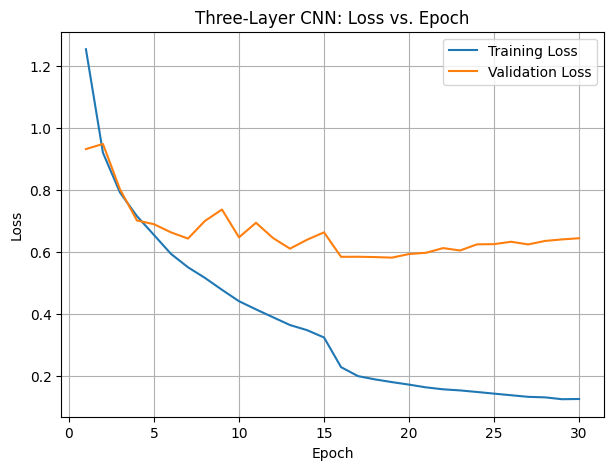

In [26]:
# Extract training and validation loss values from history
deep_epochs = list(range(1, len(deep_train_hist) + 1))
deep_train_losses = [hist[0] for hist in deep_train_hist]
deep_val_losses = [hist[0] for hist in deep_val_hist]

# Plot loss curves
plt.figure(figsize=(7, 5))

plt.plot(
    deep_epochs,
    deep_train_losses,
    label='Training Loss'
)

plt.plot(
    deep_epochs,
    deep_val_losses,
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Three-Layer CNN: Loss vs. Epoch')

plt.legend()
plt.grid()

plt.show()

# Plot Training and Validation Accuracy

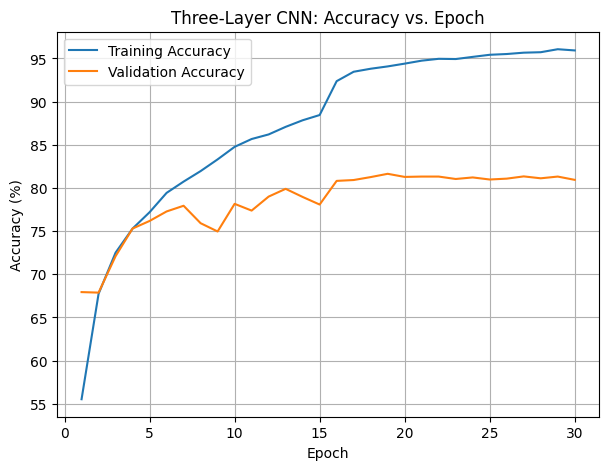

In [27]:
# Extract training and validation accuracy values from history
deep_train_accs = [hist[1] for hist in deep_train_hist]
deep_val_accs = [hist[1] for hist in deep_val_hist]

# Plot accuracy curves
plt.figure(figsize=(7, 5))

plt.plot(
    deep_epochs,
    deep_train_accs,
    label='Training Accuracy'
)

plt.plot(
    deep_epochs,
    deep_val_accs,
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Three-Layer CNN: Accuracy vs. Epoch')

plt.legend()
plt.grid()

plt.show()

# Calculate Three-Layer CNN Test Loss and Test Accuracy

In [28]:
# Final evaluation on the CIFAR-10 test dataset

deep_test_loss, deep_test_acc = evaluate(deep_model,test_loader,deep_criterion,device)

print(f'Test Loss: {deep_test_loss:.4f}')
print(f'Test Accuracy: {deep_test_acc:.2f}%')

Test Loss: 0.6531
Test Accuracy: 81.07%


# OPTIONAL: Misclassified Images

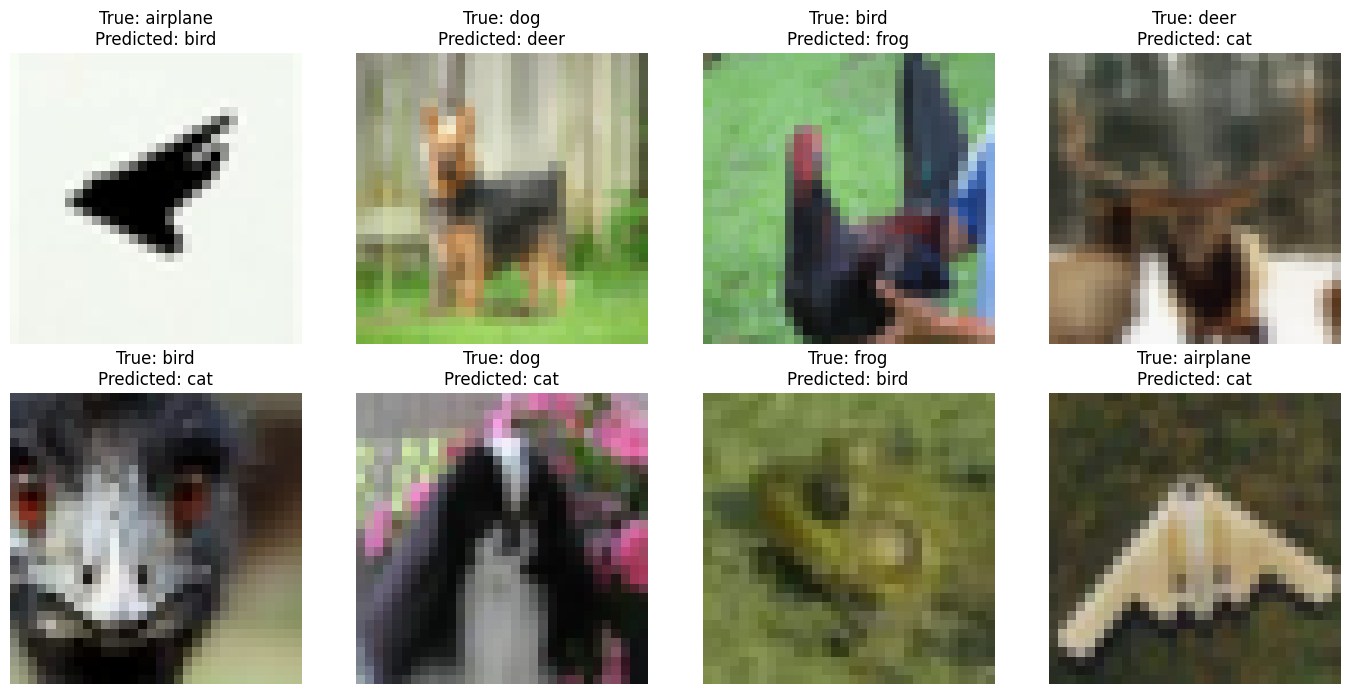

In [29]:
# CIFAR-10 class names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

deep_model.eval()

# Store incorrectly classified images
deep_misclassified = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        logits = deep_model(images)
        predictions = logits.argmax(dim=1)

        # Find incorrect predictions
        wrong = predictions != labels

        for image, true_label, pred_label in zip(
            images[wrong],
            labels[wrong],
            predictions[wrong]
        ):

            deep_misclassified.append(
                (
                    image.cpu(),
                    true_label.item(),
                    pred_label.item()
                )
            )

            # Save 8 examples
            if len(deep_misclassified) >= 8:
                break

        if len(deep_misclassified) >= 8:
            break

# CIFAR-10 normalization statistics
mean = torch.tensor(
    [0.4914, 0.4822, 0.4465]
).view(3, 1, 1)

std = torch.tensor(
    [0.2470, 0.2435, 0.2616]
).view(3, 1, 1)


plt.figure(figsize=(14, 7))

for i, (image, true_label, pred_label) in enumerate(
    deep_misclassified
):

    # Reverse normalization
    image = image * std + mean

    # Make sure pixel values stay between 0 and 1
    image = image.clamp(0, 1)

    # PyTorch images are C x H x W
    # Matplotlib expects H x W x C
    image = image.permute(1, 2, 0)

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f'True: {class_names[true_label]}\n'
        f'Predicted: {class_names[pred_label]}'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()